In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
DATA_PATH = "../data/UCI_dataset/"


SIGNALS = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

def load_inertial(split):
    X = np.stack([
        np.loadtxt(f"{DATA_PATH}{split}/Inertial Signals/{s}_{split}.txt")
        for s in SIGNALS
    ], axis=2).astype(np.float32)   # (N, 128, 9)
    y = np.loadtxt(f"{DATA_PATH}{split}/y_{split}.txt", dtype=int) - 1
    return X, y

X_train, y_train = load_inertial('train')
X_test,  y_test  = load_inertial('test')

mean = X_train.mean(axis=(0,1), keepdims=True)
std  = X_train.std(axis=(0,1),  keepdims=True) + 1e-8
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

print(f"Raw train: {X_train.shape}")  # (7352, 128, 9)
print(f"Raw test:  {X_test.shape}")   # (2947, 128, 9)

Raw train: (7352, 128, 9)
Raw test:  (2947, 128, 9)


In [22]:
print(np.unique(y_train))

[0 1 2 3 4 5]


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input



# One-hot encoding ex : 2= [0, 0, 1, 0, 0, 0] vector in R^num_classes
y_train_cat = to_categorical(y_train, num_classes=6)
y_test_cat  = to_categorical(y_test,  num_classes=6)


model1 = Sequential([
    Input(shape=(128, 9)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model2 = Sequential([
    Input(shape=(128, 9)),
    LSTM(128),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])



model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:

def plot_curves(history):
    plt.figure(figsize=(12,8))

    plt.plot(history.history['loss'],     label='Train loss')
    plt.plot(history.history['accuracy'],     label='Train accuracy')

    plt.plot(history.history['val_loss'], label='Test loss')
    plt.plot(history.history['val_accuracy'], label='Test accuracy')

    plt.title("Training session's progress over iteration")
    plt.legend(loc = 'upper right', shadow = True)
    plt.ylabel('Training Progress(Loss or Accuracy values)')
    plt.xlabel('Training Epoch')
    plt.ylim(0)

    plt.show()



def plot_cm(model):
    y_pred = np.argmax(model.predict(X_test_lstm), axis=1)
    cm = metrics.confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS)
    plt.title("Matrice de confusion")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png")
    plt.show()

In [ ]:
history1 = model1.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=1024,
    validation_data=(X_test, y_test_cat),
    verbose=1
)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3477 - loss: 1.7088 - val_accuracy: 0.5657 - val_loss: 1.5517
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5668 - loss: 1.4150 - val_accuracy: 0.5541 - val_loss: 1.2153
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 547ms/step - accuracy: 0.6001 - loss: 1.0302 - val_accuracy: 0.5823 - val_loss: 0.8717
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 380ms/step - accuracy: 0.6451 - loss: 0.7481 - val_accuracy: 0.6162 - val_loss: 0.7736
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - accuracy: 0.6907 - loss: 0.6516 - val_accuracy: 0.6753 - val_loss: 0.7265
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 446ms/step - accuracy: 0.7414 - loss: 0.5873 - val_accuracy: 0.7313 - val_loss: 0.6254
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 461ms/step - accuracy: 0.8141 - loss: 0.4994 - val_accuracy: 0.7336 - val_loss: 0.6003
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 574ms/step - accuracy: 0.8531 - loss: 0.4048 - val_accuracy: 0.7645 - val_loss: 0.5

ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 6)

In [27]:
loss1, acc1 = model1.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc1*100:.2f}%")
print(f"Loss : {loss1*100:.2f}%")


Accuracy : 89.89%
Loss : 45.82%


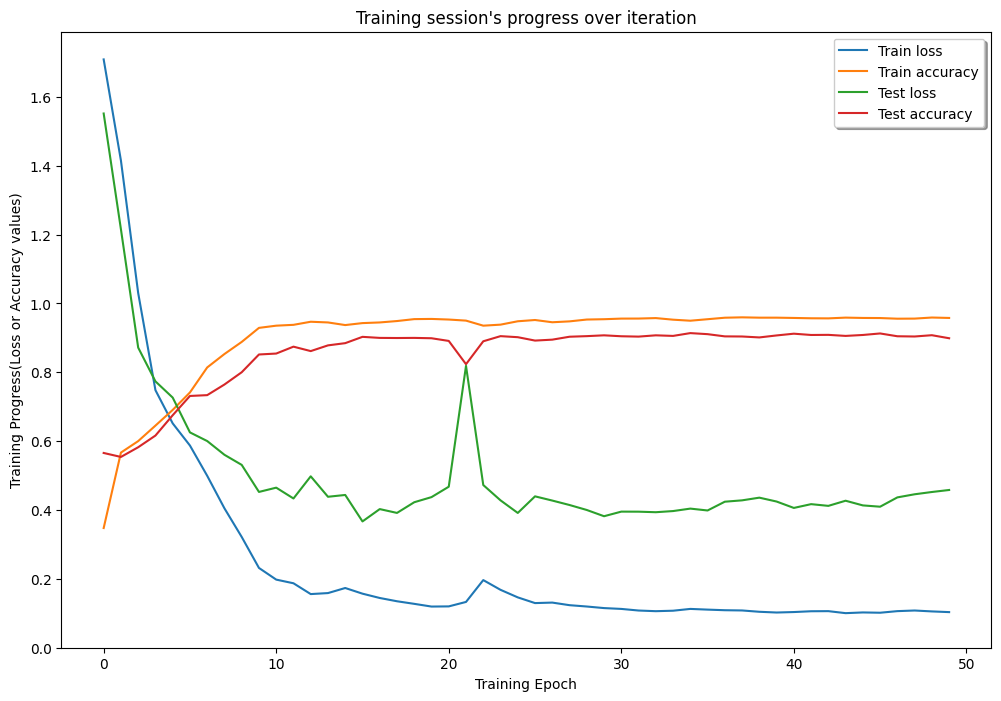

In [28]:
plot_curves(history=history1)

In [29]:
history2 = model2.fit(
    X_train, y_train_cat,
    epochs=300,
    batch_size=512,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

loss2, acc2 = model2.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc2*100:.2f}%")
print(f"Loss : {loss2*100:.2f}%")

Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 229ms/step - accuracy: 0.4300 - loss: 1.4914 - val_accuracy: 0.5663 - val_loss: 1.1944
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.6613 - loss: 0.9467 - val_accuracy: 0.6437 - val_loss: 0.7946
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.6914 - loss: 0.7103 - val_accuracy: 0.7167 - val_loss: 0.7190
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 228ms/step - accuracy: 0.7786 - loss: 0.6147 - val_accuracy: 0.7903 - val_loss: 0.5909
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.8649 - loss: 0.4151 - val_accuracy: 0.8843 - val_loss: 0.4188
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step - accuracy: 0.9041 - loss: 0.2686 - val_accuracy: 0.8541 - val_loss: 0.5231
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 309ms/step - accuracy: 0.9159 - loss: 0.2262 - val_accuracy: 0.8409 - val_loss: 0.4360
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 301ms/step - accuracy: 0.9366 - loss: 0.1777 - val_accu

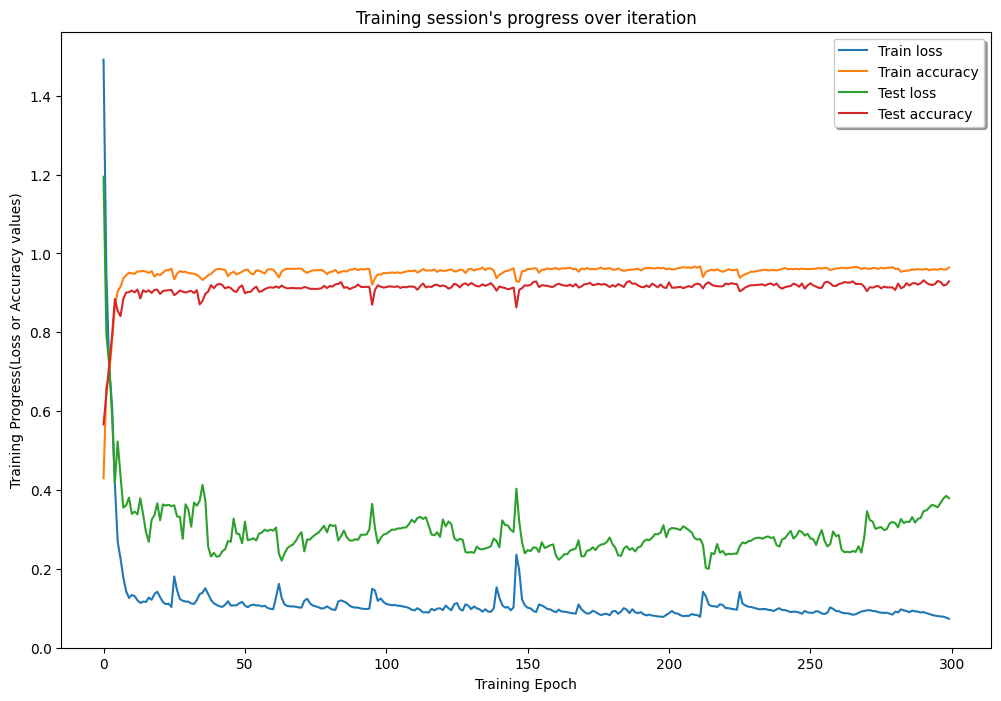

In [30]:
plot_curves(history=history2)

! Early stop !

In [34]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model3 = Sequential([
    LSTM(64, return_sequences=True,
         kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    LSTM(32, kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

model3.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train, y_train_cat,
    epochs=300,
    batch_size=256,
    validation_data=(X_test, y_test_cat),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=1
)

loss3, acc3 = model3.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nAccuracy : {acc3*100:.2f}%")
print(f"Loss : {loss3*100:.2f}%")

Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step - accuracy: 0.4245 - loss: 1.7348 - val_accuracy: 0.4432 - val_loss: 1.5506 - learning_rate: 5.0000e-04
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.5639 - loss: 1.3362 - val_accuracy: 0.6030 - val_loss: 1.1470 - learning_rate: 5.0000e-04
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.7239 - loss: 0.9605 - val_accuracy: 0.7058 - val_loss: 0.8576 - learning_rate: 5.0000e-04
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.7714 - loss: 0.7156 - val_accuracy: 0.7072 - val_loss: 0.7288 - learning_rate: 5.0000e-04
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.7995 - loss: 0.5669 - val_accuracy: 0.7520 - val_loss: 0.6230 - learning_rate: 5.0000e-04
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - accuracy: 0.8308 - loss: 0.5006 - val_accuracy: 0.8029 - val_loss: 0.5887 - learning_rate: 5.0000e-04
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - acc

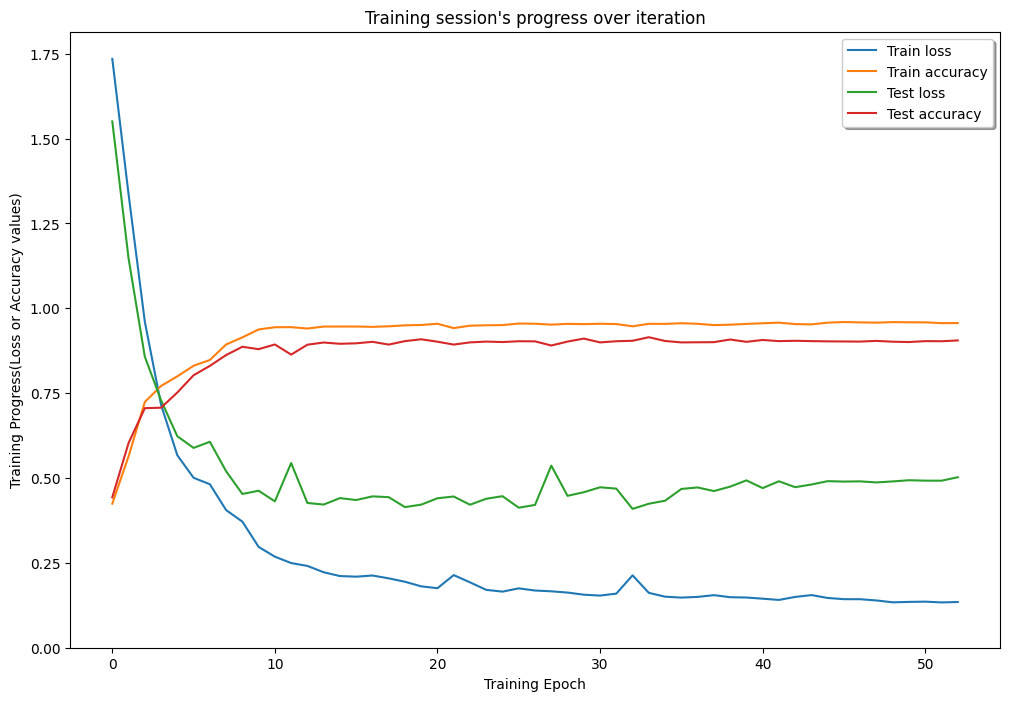

In [35]:
plot_curves(history=history3)

# CONV Models

In [38]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

model_cnn = Sequential([
    Input(shape=(128, 9)),
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(561, 1)),
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=1),
    Dropout(0.4),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(X_train.shape)

history_cnn = model_cnn.fit(
    X_train, y_train_cat,
    epochs=300,
    batch_size=256,
    validation_data=(X_test, y_test_cat),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=1
)

loss_cnn, acc_cnn = model_cnn.evaluate(X_test, y_test_cat, verbose=0)

print(f"\nAccuracy CNN : {loss_cnn*100:.2f}%")
print(f"Loss CNN : {acc_cnn*100:.2f}%")

(7352, 128, 9)
Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7164 - loss: 0.7539 - val_accuracy: 0.8531 - val_loss: 0.5165 - learning_rate: 5.0000e-04
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9312 - loss: 0.2162 - val_accuracy: 0.9067 - val_loss: 0.2895 - learning_rate: 5.0000e-04
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9479 - loss: 0.1390 - val_accuracy: 0.9040 - val_loss: 0.2603 - learning_rate: 5.0000e-04
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9525 - loss: 0.1133 - val_accuracy: 0.9091 - val_loss: 0.2719 - learning_rate: 5.0000e-04
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9546 - loss: 0.1042 - val_accuracy: 0.9094 - val_loss: 0.2730 - learning_rate: 5.0000e-04
Epoch 6/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9580 - loss: 0.0964 - val_accuracy: 0.9087 - val_loss: 0.2831 - learning_rate: 5.0000e-04
Epoch 7/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/st

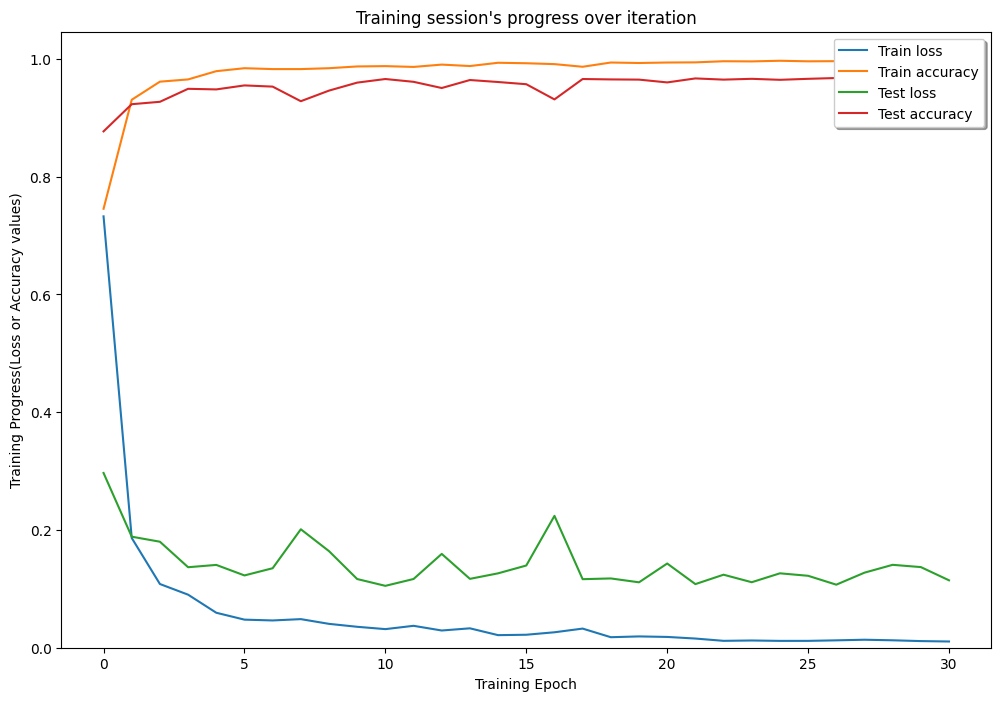

In [ ]:
plot_curves(history=history_cnn)

In [40]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten


model_deepconv_lstm = Sequential([
    Input(shape=(128,9)),
    Conv1D(64, kernel_size=11, activation='relu', padding='same',
           input_shape=(561, 1)),
    Conv1D(64, kernel_size=11, activation='relu', padding='same'),
    Conv1D(64, kernel_size=11, activation='relu', padding='same'),
    Conv1D(64, kernel_size=11, activation='relu', padding='same'),

    Dropout(0.5),

    LSTM(128),

    Dropout(0.5),

    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

model_deepconv_lstm.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_deepconv_lstm = model_deepconv_lstm.fit(
    X_train, y_train_cat,
    epochs=300,
    batch_size=512,
    validation_data=(X_test, y_test_cat),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=1
)

loss_deepconv_lstm, acc_deepconv_lstm = model_deepconv_lstm.evaluate(
    X_test, y_test_cat, verbose=0
)

print(f"\nAccuracy DeepConvLSTM : {acc_deepconv_lstm*100:.2f}%")
print(f"Loss DeepConvLSTM : {loss_deepconv_lstm:.4f}")

Epoch 1/300


/home/hiba/HAR_models/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 471ms/step - accuracy: 0.2885 - loss: 1.7610 - val_accuracy: 0.3468 - val_loss: 1.6931 - learning_rate: 1.0000e-04
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 627ms/step - accuracy: 0.3542 - loss: 1.6016 - val_accuracy: 0.3410 - val_loss: 1.4346 - learning_rate: 1.0000e-04
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 687ms/step - accuracy: 0.3524 - loss: 1.3958 - val_accuracy: 0.3607 - val_loss: 1.2516 - learning_rate: 1.0000e-04
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 706ms/step - accuracy: 0.4155 - loss: 1.2308 - val_accuracy: 0.5463 - val_loss: 1.0971 - learning_rate: 1.0000e-04
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 661ms/step - accuracy: 0.5739 - loss: 1.0433 - val_accuracy: 0.6060 - val_loss: 0.8780 - learning_rate: 1.0000e-04
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 681ms/step - accuracy: 0.6586 - loss: 0.8411 - val_accuracy: 0.7669 - val_loss: 0.6777 - learning_rate: 1.0000e-04
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 674ms/step - accuracy: 

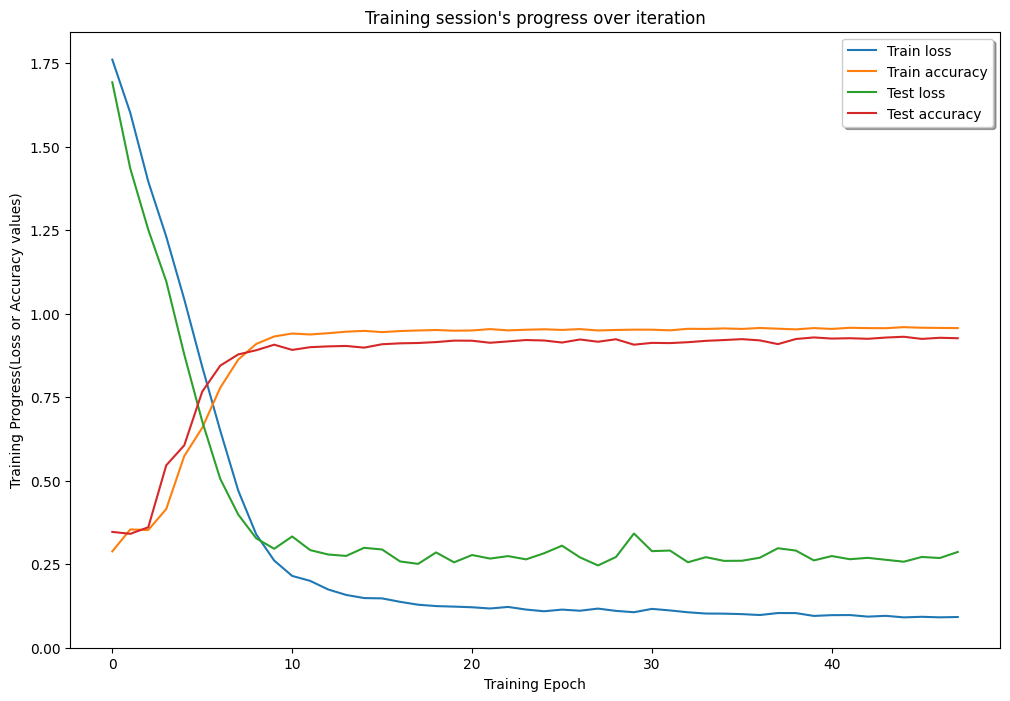

In [41]:
plot_curves(history=history_deepconv_lstm)

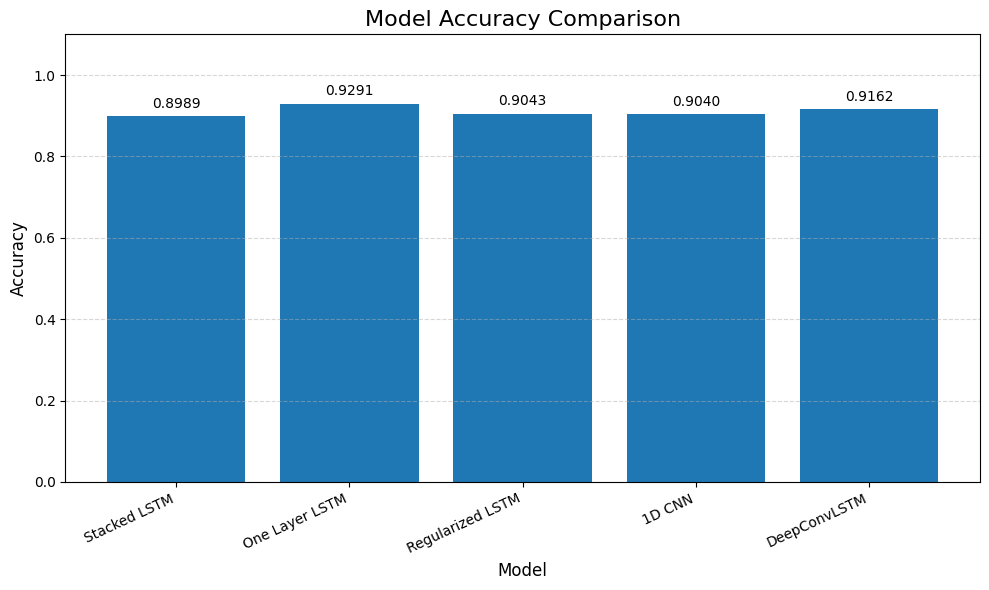

In [42]:
import matplotlib.pyplot as plt

accuracy_by_model = {
    'Stacked LSTM': acc1,
    'One Layer LSTM': acc2,
    'Regularized LSTM': acc3,
    '1D CNN': acc_cnn,
    'DeepConvLSTM': acc_deepconv_lstm,
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(accuracy_by_model.keys(), accuracy_by_model.values(), color='tab:blue')
ax.set_ylim(0, 1.1)
ax.set_title('Model Accuracy Comparison', fontsize=16)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()
